In [3]:
import pandas as pd

df = pd.read_csv("dataset/IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [8]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [9]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


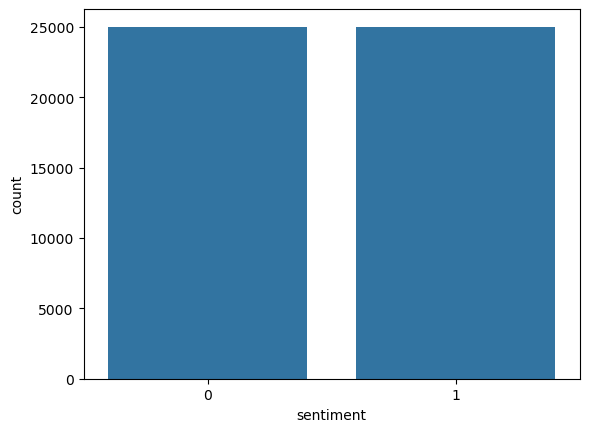

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.show()

# import seaborn as sns
# Imports the Seaborn library, which is used for statistical data visualization.

# import matplotlib.pyplot as plt
# Imports Matplotlib's pyplot module, used for creating and displaying plots.

# sns.countplot(x='sentiment', data=df)
# Creates a countplot that shows the frequency of each category in the 'Sentiment' column.
# It visualizes how many samples belong to each class (0 = Negative, 1 = Postive).

# plt.show()
# Displays the generated plot on the screen.

# 25000->Positive
# 25000-> Negative

In [12]:
# FEATURE ENGINEERING

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download required NLTK resources (run once)
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Keep only alphabets
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Tokenization (split into words)
    words = text.split()
    
    # Remove stopwords + lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Join back into a single string
    text = ' '.join(words)
    
    return text

# Apply preprocessing to dataset
df['review'] = df['review'].apply(preprocess_text)

# This function is used to preprocess raw text data before feeding it into the machine learning model.
# The main purpose is to clean, normalize, and standardize the text so that the model can learn meaningful patterns without noise.

# Importing required libraries
# nltk is used for natural language processing tasks such as stopwords removal and lemmatization.
# re (Regular Expressions) is used for text cleaning operations like removing unwanted characters and symbols.

# Downloading NLTK resources
# stopwords, wordnet, and omw-1.4 are required datasets for text preprocessing tasks.
# These are downloaded once to enable stopwords filtering and lemmatization.

# Initializing tools
# stop_words contains a list of commonly used words (e.g., "is", "the", "and") that do not add meaningful information in sentiment analysis.
# WordNetLemmatizer is used to convert words into their base or root form for better text normalization.

# Lowercasing text
# All text is converted into lowercase to maintain uniformity.
# This ensures that words like "Good" and "good" are treated as the same feature.

# Removing HTML tags
# HTML tags such as <br />, <div>, etc. are removed because they do not contain meaningful sentiment information.

# Removing special characters and numbers
# All characters except alphabets are removed to eliminate noise such as punctuation, symbols, and digits.

# Tokenization (splitting text into words)
# The cleaned sentence is split into individual words so that each word can be processed separately.

# Stopwords removal + Lemmatization
# Stopwords are removed to eliminate common but unimportant words that do not contribute to sentiment detection.
# Lemmatization is applied to reduce words to their base form (e.g., running → run, better → good).
# This helps in reducing feature complexity and improving model understanding.

# Joining words back into a sentence
# After processing, words are combined back into a single string so it can be used in vectorization (TF-IDF).

# Returning cleaned text
# Finally, the fully preprocessed text is returned for feature extraction and model training.

# Applying function to dataset
# The preprocessing function is applied to every review in the dataset.
# This ensures that all text data is consistently cleaned and normalized before being converted into numerical format for machine learning models.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rizwa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rizwa\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\rizwa\AppData\Roaming\nltk_data...


In [13]:
df.head()

,review,sentiment
0,one reviewer mentioned watching oz episode hoo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically family little boy jake think zombie ...,0
4,petter mattei love time money visually stunnin...,1


In [14]:
from sklearn.model_selection import train_test_split

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)



# Importing TF-IDF Vectorizer from sklearn
# TF-IDF (Term Frequency - Inverse Document Frequency) is used to convert text data into numerical format
# so that machine learning models can understand and process it.

# Initializing TF-IDF Vectorizer
# max_features=5000 means we will only keep the top 5000 most important words in the dataset
# This reduces computational cost and removes less important words from the feature space

# Fitting and transforming training data
# fit_transform learns the vocabulary from the training dataset and converts text into numerical feature vectors
# This step builds the TF-IDF representation based only on training data to avoid data leakage

# Transforming test data
# transform is used instead of fit_transform to ensure the same vocabulary is used for test data
# This prevents data leakage and ensures consistent feature representation between train and test sets


#👉 “TF-IDF selects the top 5000 most relevant words from the dataset and assigns each word a numerical importance score
# based on how frequently it appears in a specific review and how unique it is across all reviews.”

In [20]:

feature_names = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(X_train_tfidf[0].toarray(), columns=feature_names)

print(df_tfidf)
# Sentiment text is now converted into numeric matrix

   aaron  abandoned  abc   ability  able  absence  absent  absolute  \
0    0.0        0.0  0.0  0.082863   0.0      0.0     0.0       0.0   

   absolutely  absurd  ...  yesterday  yet  york  young  younger  youngster  \
0    0.066571     0.0  ...        0.0  0.0   0.0    0.0      0.0        0.0   

   youth  zero  zombie  zone  
0    0.0   0.0     0.0   0.0  

[1 rows x 5000 columns]


In [21]:
#LOGISTC REGRESSION MODEL

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# Train the model using TF-IDF features
# Model learns relationship between review text and sentiment labels
model.fit(X_train_tfidf, y_train)

# Make predictions on test data
# Model predicts sentiment (positive/negative) for unseen reviews
y_pred = model.predict(X_test_tfidf)


In [23]:
from sklearn.metrics import accuracy_score, classification_report
# Evaluate model performance using accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8893


In [24]:
# Detailed classification report (precision, recall, F1-score)
# This shows how well the model performs for each class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



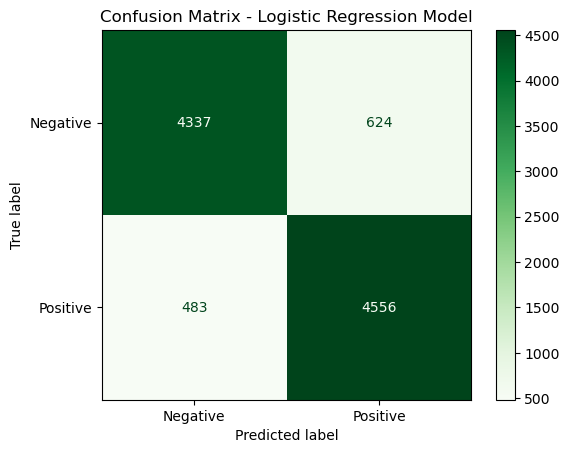

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Negative", "Positive"])

# Plot
disp_lr.plot(cmap="Greens")
plt.title("Confusion Matrix - Logistic Regression Model")
plt.show()

In [26]:

# SUPPORT VECTOR MACHINE MODEL
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize SVM model
# LinearSVC is best for text data (TF-IDF) because it is fast and works well in high-dimensional space
svm_model = LinearSVC()

# Train the model using TF-IDF features
# Model learns the optimal decision boundary (hyperplane) between positive and negative reviews
svm_model.fit(X_train_tfidf, y_train)

# Predict sentiment on test data
# Model assigns class labels (0 = negative, 1 = positive)
y_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

# Detailed performance report
# Includes precision, recall, and F1-score for each class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8818

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



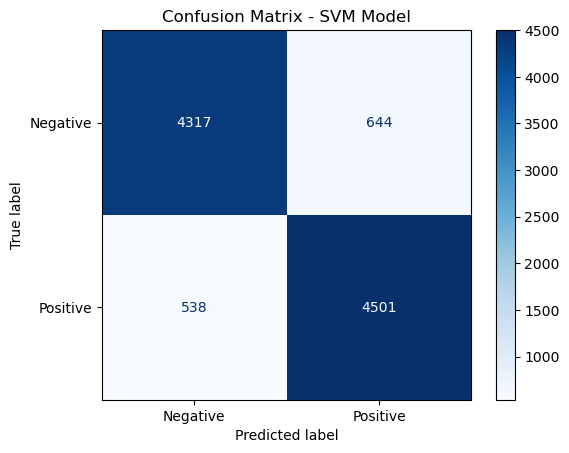

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Display confusion matrix in a visual format
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])

# Plot
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM Model")
plt.show()

In [32]:
# Model Comparsion

import pandas as pd

# Create comparison dictionary for 2 models only
results = {
    "Model": [
        "Logistic Regression",
        "SVM (LinearSVC)"
    ],
    "Accuracy": [
        accuracy,
        accuracy_svm
    ]
}

# Convert into DataFrame
comparison_df = pd.DataFrame(results)

# Sort by best accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

# Display table
print(comparison_df)

                 Model  Accuracy
0  Logistic Regression    0.8893
1      SVM (LinearSVC)    0.8818


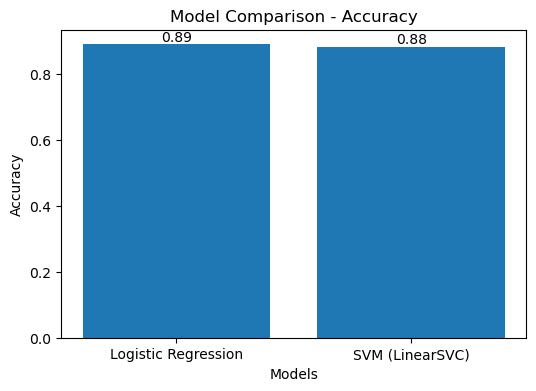

In [34]:
import matplotlib.pyplot as plt

# Model names
models = ["Logistic Regression", "SVM (LinearSVC)"]

# Accuracy values (from your trained models)
accuracies = [accuracy, accuracy_svm]

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

# Title and labels
plt.title("Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Show values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center')

# Display plot
plt.show()

In [42]:
import joblib

joblib.dump(model, "sentiment_model.pkl")


# import joblib
# Imports the joblib library, used for saving and loading trained machine learning models.

# joblib.dump(model, "sentiment_model.pkl")
# Saves the trained Logistic Regression model into a file named "sentiment_model.pkl".
# This allows the model to be reused later without retraining.


['sentiment_model.pkl']